# Day 08. Exercise 03
# Overfitting

## 0. Imports

In [1]:
import warnings
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import cross_val_score
from joblib import dump, load

warnings.filterwarnings('ignore')
pd.options.display.max_rows = 10

## 1. Preprocessing

1. Read the file `dayofweek.csv` to a dataframe.
2. Using `train_test_split` with parameters `test_size=0.2`, `random_state=21` get `X_train`, `y_train`, `X_test`, `y_test`.
3. Using, for example, `value_counts()` to check if the distribution of classes is similar in train and test.
4. Use the additional parameter `stratify=` and check the distribution again, now it should be more or less similar in both datasets.

In [2]:
df = pd.read_csv('../data/dayofweek.csv')
X = df.drop('dayofweek', axis=1)
y = df['dayofweek']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

print([round(x/sum(y_train.value_counts()), 4) for x in y_train.value_counts()])
print([round(x/sum(y_test.value_counts()),4) for x in y_test.value_counts()])

[0.2322, 0.2129, 0.1647, 0.1602, 0.0927, 0.0779, 0.0593]
[0.2456, 0.2041, 0.1627, 0.1538, 0.0917, 0.071, 0.071]


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21, stratify=y)

print([round(x/sum(y_train.value_counts()),4) for x in y_train.value_counts()])
print([round(x/sum(y_test.value_counts()), 4) for x in y_test.value_counts()])

[0.2344, 0.2114, 0.1625, 0.161, 0.0883, 0.0809, 0.0616]
[0.2367, 0.2101, 0.1627, 0.1598, 0.0888, 0.0799, 0.0621]


## 2. Baseline models

1. Train exactly the same baseline models from the previous exercise and calculate the accuracies using the test dataset with stratification.
2. Did all the models show the similar values of the metric? Which one has the largest difference comparing the current exercise and the previous? Put the answer to the markdown cell in the end of the section.

### a. Logreg

In [4]:
log_reg = LogisticRegression(random_state=21, fit_intercept=False, solver='saga').fit(X_train, y_train)

predict_col = log_reg.predict(X_test)
acc = accuracy_score(predict_col, y_test)
acc

0.6272189349112426

### b. SVM

In [5]:
for name in ['sigmoid', 'rbf', 'poly', 'linear']:
    svc = OneVsRestClassifier(SVC(random_state=21, probability=True, kernel=name)).fit(X_train, y_train)

    predict_col = svc.predict(X_test)
    acc = accuracy_score(predict_col, y_test)
    print(name, acc)

sigmoid 0.2692307692307692
rbf 0.8431952662721893
poly 0.8727810650887574
linear 0.6183431952662722


### c. Decision tree

In [6]:
for x in range(1, 5):
    dec_tree_class = tree.DecisionTreeClassifier(random_state=42, max_depth=x).fit(X_train.values, y_train.values)

    predict = dec_tree_class.predict(X_test.values)
    acc = accuracy_score(predict, y_test)
    print(acc)

0.3668639053254438
0.4556213017751479
0.4822485207100592
0.5295857988165681


### d. Random forest

In [7]:
for depth in range(5, 26, 5):
    for estimators in range(25, 101, 25):
        random_forest = RandomForestClassifier(random_state=21, max_depth=depth, n_estimators=estimators).fit(X_train.values, y_train.values)

        predict = random_forest.predict(X_test.values)
        acc = accuracy_score(predict, y_test)
        print(f'{depth=} {estimators=} acc=', acc)

depth=5 estimators=25 acc= 0.5739644970414202
depth=5 estimators=50 acc= 0.6005917159763313
depth=5 estimators=75 acc= 0.5946745562130178
depth=5 estimators=100 acc= 0.6005917159763313
depth=10 estimators=25 acc= 0.8136094674556213
depth=10 estimators=50 acc= 0.8402366863905325
depth=10 estimators=75 acc= 0.8550295857988166
depth=10 estimators=100 acc= 0.8550295857988166
depth=15 estimators=25 acc= 0.893491124260355
depth=15 estimators=50 acc= 0.908284023668639
depth=15 estimators=75 acc= 0.908284023668639
depth=15 estimators=100 acc= 0.9171597633136095
depth=20 estimators=25 acc= 0.9171597633136095
depth=20 estimators=50 acc= 0.9171597633136095
depth=20 estimators=75 acc= 0.9230769230769231
depth=20 estimators=100 acc= 0.9230769230769231
depth=25 estimators=25 acc= 0.9230769230769231
depth=25 estimators=50 acc= 0.9289940828402367
depth=25 estimators=75 acc= 0.9319526627218935
depth=25 estimators=100 acc= 0.9319526627218935


Did all the models show the similar values of the metric?  
Answer: Yes  
Which one has the largest difference comparing the current exercise and the previous?  
Answer: Random Forest

## 3. Crossvalidation

We could play with parameters of the model trying to achive a better accuracy on the test dataset, but it is a bad practice. It leads us again to overfitting. Test dataset is only for checking quality of a final model.

But there is another way of solving the problem – crossvalidation. It does not use test dataset, but creates one more split of train dataset. Again, there are different ways of doing it, but the common thing is that there is a validation dataset that is used for hyperparameters optimization.

1. Using `cross_val_score` with `cv=10` calculate the mean accuracy and standard deviation for every model that you used before (logreg with `solver='liblinear'`, SVC, decision tree, random forest).

### a. Logreg

In [8]:
log_reg = LogisticRegression(random_state=21, fit_intercept=False, solver='liblinear').fit(X_train, y_train)
predicted = cross_val_score(log_reg, X_train, y_train, cv=10)
print(f"{predicted.mean():0.4f} mean accuracy with a standard deviation of {predicted.std():0.4f}")

0.5816 mean accuracy with a standard deviation of 0.0253


### b. SVM

In [9]:
predicted = cross_val_score(svc, X_train, y_train, cv=10)
print(f"{predicted.mean():0.4f} mean accuracy with a standard deviation of {predicted.std():0.4f}")

0.5705 mean accuracy with a standard deviation of 0.0370


### c. Decision tree

In [10]:
predicted = cross_val_score(dec_tree_class, X_train, y_train, cv=10)
print(f"{predicted.mean():0.4f} mean accuracy with a standard deviation of {predicted.std():0.4f}")

0.5089 mean accuracy with a standard deviation of 0.0319


### d. Random forest

In [11]:
predicted = cross_val_score(random_forest, X_train, y_train, cv=10)
print(f"{predicted.mean():0.4f} mean accuracy with a standard deviation of {predicted.std():0.4f}")

0.9117 mean accuracy with a standard deviation of 0.0174


## 4. Optimization

1. Choose the best model and play a little bit with the parameters on cross-validation, find a good enough parameter or a combination of the parameters.
2. Calculate the accuracy for the final model on the test dataset.
3. Draw a plot that displays the top-10 most  important features for that model.
4. Save the model using `joblib`.
5. Load the model, make predictions for the test dataset and calculate the accuracy.

In [12]:
# random forest
for depth in range(5, 26, 5):
    for estimators in range(25, 101, 25):
        random_forest = RandomForestClassifier(random_state=21, max_depth=depth, n_estimators=estimators).fit(X_train.values, y_train.values)

        predicted = cross_val_score(random_forest, X_train, y_train, cv=10)
        print(f"{predicted.mean():0.4f} mean accuracy with a standard deviation of {predicted.std():0.4f} {depth=} {estimators=}")

0.5727 mean accuracy with a standard deviation of 0.0297 depth=5 estimators=25
0.5771 mean accuracy with a standard deviation of 0.0290 depth=5 estimators=50
0.5808 mean accuracy with a standard deviation of 0.0181 depth=5 estimators=75
0.5823 mean accuracy with a standard deviation of 0.0237 depth=5 estimators=100
0.7886 mean accuracy with a standard deviation of 0.0258 depth=10 estimators=25
0.8034 mean accuracy with a standard deviation of 0.0336 depth=10 estimators=50
0.8049 mean accuracy with a standard deviation of 0.0356 depth=10 estimators=75
0.8049 mean accuracy with a standard deviation of 0.0332 depth=10 estimators=100
0.8806 mean accuracy with a standard deviation of 0.0282 depth=15 estimators=25
0.8939 mean accuracy with a standard deviation of 0.0269 depth=15 estimators=50
0.8961 mean accuracy with a standard deviation of 0.0185 depth=15 estimators=75
0.8946 mean accuracy with a standard deviation of 0.0144 depth=15 estimators=100
0.9095 mean accuracy with a standard devi

In [13]:
# best depth=25, est=75
random_forest = RandomForestClassifier(random_state=21, max_depth=25, n_estimators=75).fit(X_train.values, y_train.values)
acc = accuracy_score(predict, y_test)
predicted = cross_val_score(random_forest, X_train, y_train, cv=10)
acc_cross = f"{predicted.mean():0.4f} mean accuracy with a standard deviation of {predicted.std():0.4f} {depth=} {estimators=}"
print(f'acc =', round(acc, 4),'\n' , acc_cross)

acc = 0.932 
 0.9147 mean accuracy with a standard deviation of 0.0194 depth=25 estimators=100


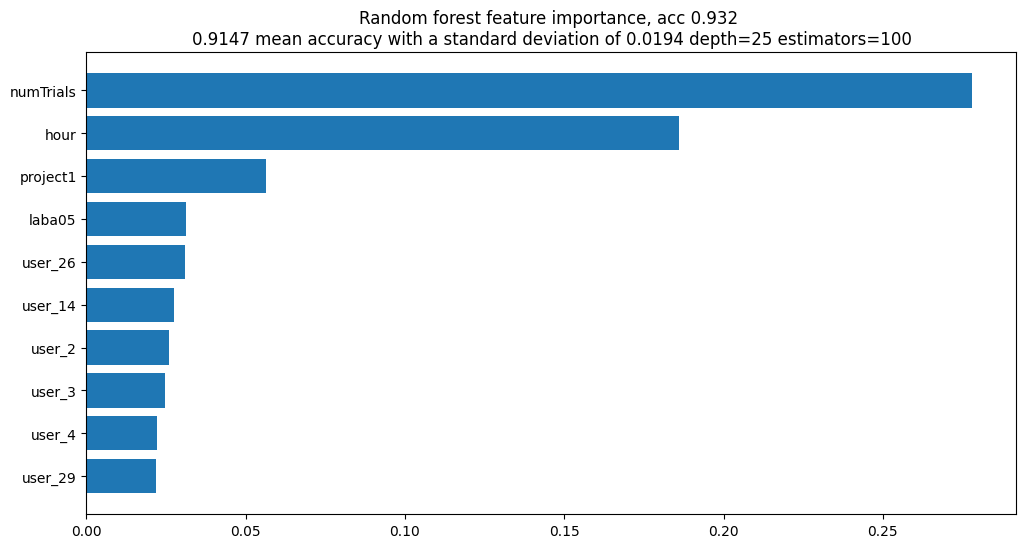

In [14]:
def plot_importance(coef: list[int | float], names: list[str], n_top: int, acc: float, acc_cross: str) -> None:
    features_names = X_train.columns
    
    coef = [(features_names[num], x) for num, x in enumerate(coef)]
    coef = sorted(coef, key=lambda x : x[1], reverse=True)
    names, coef = [x[0] for x in coef], [x[1] for x in coef]

    plt.figure(figsize=(12, 6))
    plt.barh(range(len(names))[:n_top], coef[:n_top][::-1], align='center')
    plt.yticks(range(len(names[:n_top])), labels=names[:n_top][::-1])

    plt.title(f'Random forest feature importance, acc {acc} \n{acc_cross}')
    plt.show()


plot_importance(random_forest.feature_importances_, X_train.columns, 10, round(acc, 4), acc_cross)

In [15]:
# Save the model using `joblib`.
with open("random_forest.joblib", "wb") as f:
    dump(random_forest, f, protocol=5)

In [16]:
with open("random_forest.joblib", "rb") as f:
    random_forest = load(f)

predict = random_forest.predict(X_test.values)
acc = accuracy_score(predict, y_test)
acc

0.9319526627218935